# Early Stopping Demos

In [61]:
# imports
import wandb
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd

from aquarel import load_theme
import dotenv
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from tqdm import tqdm
import typer

In [207]:
# import three files: coral_val_wer.csv, fleurs_val_wer.csv, and lillelyd_train_wer.csv
def load_wer_data(model_name="parakeet"):
    coral_wer = pd.read_csv(f"coral_val_wer_{model_name}.csv")
    fleurs_wer = pd.read_csv(f"fleurs_val_wer_{model_name}.csv")
    lillelyd_wer = pd.read_csv(f"lillelyd_train_wer_{model_name}.csv")
    return coral_wer, fleurs_wer, lillelyd_wer

def process_df(df, dataset_name, model_name="parakeet"):
    # renmake trainer/global_step column to step
    df = df.rename(columns={"trainer/global_step": "step"})
    if model_name == "parakeet":
        match dataset_name:
            case "coral":
                df = df.rename(columns={f"parakeet-finetune_lillelyd_27585228 - coralval_wer": f"{dataset_name}_wer"})
            case "fleurs":
                df = df.rename(columns={f"parakeet-finetune_lillelyd_27585228 - fleursval_wer": f"{dataset_name}_wer"})
            case "lillelyd":
                df = df.rename(columns={f"parakeet-finetune_lillelyd_27585228 - training_batch_wer": f"{dataset_name}_wer"})
    else:
        match dataset_name:
            case "coral":
                df = df.rename(columns={f"canary-finetune_SA_SP_lillelyd_cv-4_27652665 - coralval_wer": f"{dataset_name}_wer"})
            case "fleurs":
                df = df.rename(columns={f"canary-finetune_SA_SP_lillelyd_cv-4_27652665 - fleursval_wer": f"{dataset_name}_wer"})
            case "lillelyd":
                df = df.rename(columns={f"canary-finetune_SA_SP_lillelyd_cv-4_27652665 - training_batch_wer": f"{dataset_name}_wer"})
    # rename parakeet-finetune_lillelyd_27585228 - coralval_wer to dataset_name_val_wer
    

    # due to inconsistencies in logging, some of the steps are off on the training batch wer
    # for lillelyd, we add rows around each step to fill in the gaps such that 
    # # if we have step 79 with wer 0.5 we add step 77 and 78 with wer 0.5 and step 80 and 81 with wer 0.5
    if model_name == "parakeet":
        if dataset_name == "lillelyd":
            new_rows = []
            for index, row in df.iterrows():
                step = row["step"]
                wer = row[f"{dataset_name}_wer"]
                for i in range(-2, 3):
                    new_rows.append({"step": step + i, f"{dataset_name}_wer": wer})
            df = pd.DataFrame(new_rows).drop_duplicates(subset=["step"])
    else:
        #pass
        # for canary, we have every step logged correctly, so we need to compute the average for step 0 to 26, 27 to 53, etc.
        if dataset_name == "lillelyd":
            steps = [26, 54, 82, 110, 138, 166, 194, 222, 250, 278, 306, 334, 362, 390, 418, 446, 474, 502, 530, 558, 586, 614, 642, 670]
            df = df.sort_values(by="step")
            new_rows = []
            ranges = range(0, df["step"].max() + 1, 27)
            for i, (start, end) in enumerate(zip(ranges, steps)):
                # instead of full subset, take the last five steps in the range
                #subset = df[(df["step"] >= start) & (df["step"] < end)]
                subset = df[(df["step"] >= end - 5) & (df["step"] <= end)]
                if not subset.empty:
                    avg_wer = subset[f"{dataset_name}_wer"].mean()
                    # we then append a row with step 26, 53, 80, etc. and the average wer
                    
                    new_rows.append({"step": steps[i], f"{dataset_name}_wer": avg_wer})
                    
            df = pd.DataFrame(new_rows)    

    # drop all columns except step and dataset_name_val_wer
    df = df[["step", f"{dataset_name}_wer"]]
    return df

def merge_wer_data(coral_wer, fleurs_wer, lillelyd_wer):
    # merge the three dataframes on step
    merged_wer = pd.merge(coral_wer, fleurs_wer, on="step", how="outer")
    merged_wer = pd.merge(merged_wer, lillelyd_wer, on="step", how="outer")

    # drop rows with any NaN values
    merged_wer = merged_wer.dropna()
    # rename step to epoch and divide by 27
    merged_wer["step"] = merged_wer["step"].astype(int) + 1
    merged_wer["epoch"] = (merged_wer["step"] / 27).astype(int)
    return merged_wer

def main(model_name="parakeet"):
    coral_wer, fleurs_wer, lillelyd_wer = load_wer_data(model_name=model_name)

    coral_wer = process_df(coral_wer, "coral", model_name=model_name)
    fleurs_wer = process_df(fleurs_wer, "fleurs", model_name=model_name)
    lillelyd_wer = process_df(lillelyd_wer, "lillelyd", model_name=model_name)

    merged_wer = merge_wer_data(coral_wer, fleurs_wer, lillelyd_wer)

    return merged_wer
    

In [217]:
merged_df = main("canary")

In [218]:
merged_df

,step,coral_wer,fleurs_wer,lillelyd_wer,epoch
0,27,0.141818,0.192312,0.351631,1
1,55,0.166708,0.261231,0.283113,2
2,83,0.182378,0.296976,0.214806,3
3,111,0.194410,0.325621,0.102078,4
4,139,0.202721,0.346432,0.071179,5
5,167,0.209047,0.358551,0.037411,6
6,195,0.216282,0.358673,0.040772,7
7,223,0.220293,0.382666,0.031853,8
8,251,0.226784,0.379851,0.012488,9
9,279,0.228810,0.374220,0.006316,10


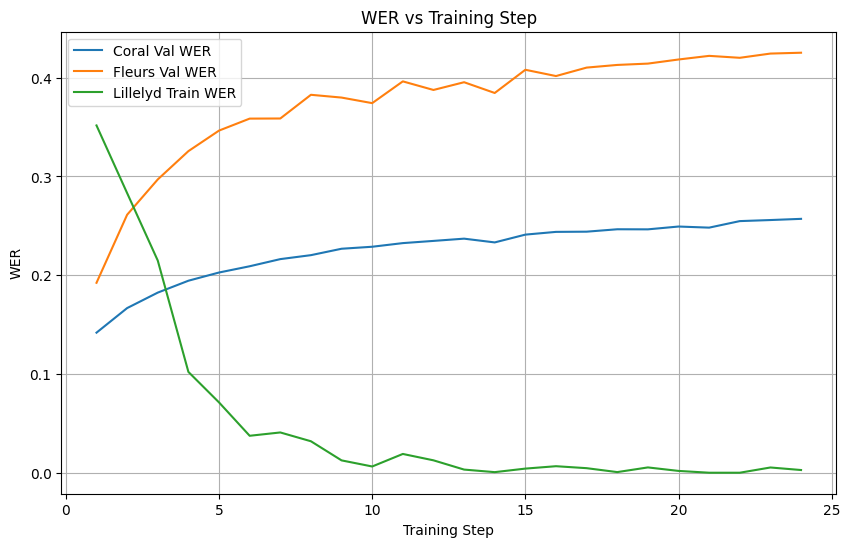

In [219]:
# plot the three WERs against step
plt.figure(figsize=(10, 6))
plt.plot(merged_df["epoch"], merged_df["coral_wer"], label="Coral Val WER")
plt.plot(merged_df["epoch"], merged_df["fleurs_wer"], label="Fleurs Val WER")
plt.plot(merged_df["epoch"], merged_df["lillelyd_wer"], label="Lillelyd Train WER")
plt.xlabel("Training Step")
plt.ylabel("WER")
plt.title("WER vs Training Step")
plt.legend()
plt.grid()
plt.show()

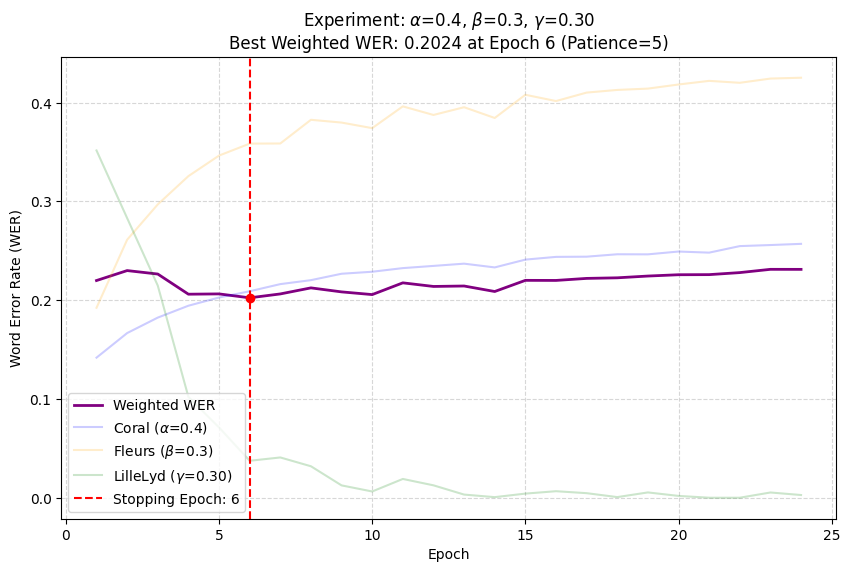

In [213]:
import matplotlib.pyplot as plt

def run_wer_experiment(merged_df, alpha=0.5, beta=0.0, patience=5):
    """
    Computes weighted WER, finds the early stopping point, and plots the results.
    Weights: coral (alpha), fleurs (beta), lillelyd (1 - alpha - beta).
    """
    # 1. Calculate Weighted WER
    gamma = 1 - alpha - beta
    df = merged_df.copy()
    df["weighted_wer"] = (alpha * df["coral_wer"] +
                          beta * df["fleurs_wer"] +
                          gamma * df["lillelyd_wer"])

    # 2. Early Stopping Logic
    best_wer = float("inf")
    best_epoch = -1
    counter = 0

    for _, row in df.iterrows():
        epoch, current_wer = row["epoch"], row["weighted_wer"]

        if current_wer < best_wer:
            best_wer = current_wer
            best_epoch = epoch
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    # 3. Visualization
    plt.figure(figsize=(10, 6))
    
    # Plot main metric
    plt.plot(df["epoch"], df["weighted_wer"], label="Weighted WER", color="purple", linewidth=2)
    
    # Plot components (faded)
    plt.plot(df["epoch"], df["coral_wer"], label=f"Coral ($\\alpha$={alpha})", color="blue", alpha=0.2)
    plt.plot(df["epoch"], df["fleurs_wer"], label=f"Fleurs ($\\beta$={beta})", color="orange", alpha=0.2)
    plt.plot(df["epoch"], df["lillelyd_wer"], label=f"LilleLyd ($\\gamma$={gamma:.2f})", color="green", alpha=0.2)
    
    # Highlight early stopping point
    if best_epoch != -1:
        plt.axvline(x=best_epoch, color="red", linestyle="--", 
                    label=f"Stopping Epoch: {int(best_epoch)}")
        plt.scatter(best_epoch, best_wer, color="red", zorder=5)

    plt.xlabel("Epoch")
    plt.ylabel("Word Error Rate (WER)")
    plt.title(f"Experiment: $\\alpha$={alpha}, $\\beta$={beta}, $\\gamma$={gamma:.2f}\nBest Weighted WER: {best_wer:.4f} at Epoch {int(best_epoch)} (Patience={patience})")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()

    return best_epoch, best_wer

# --- MODIFY ONLY THESE VALUES ---
best_epoch, best_wer = run_wer_experiment(merged_df, alpha=0.4, beta=0.3, patience=5)

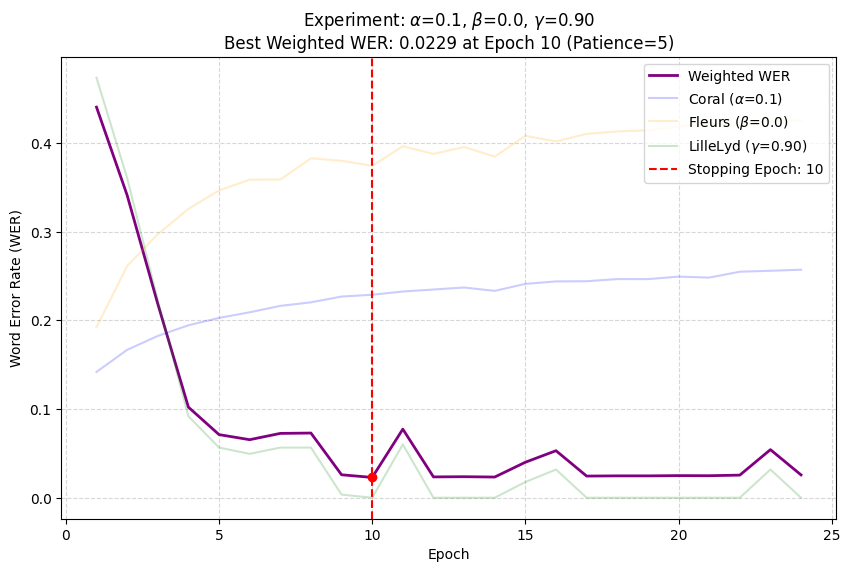

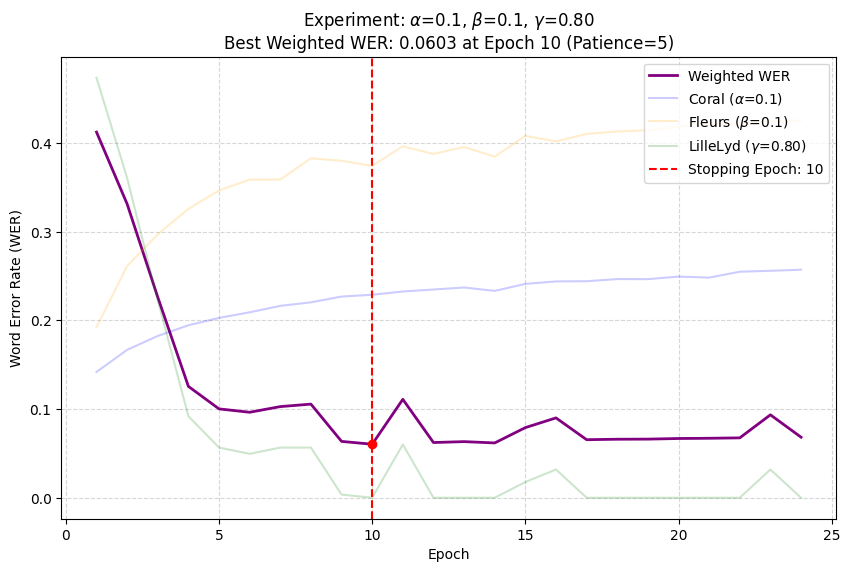

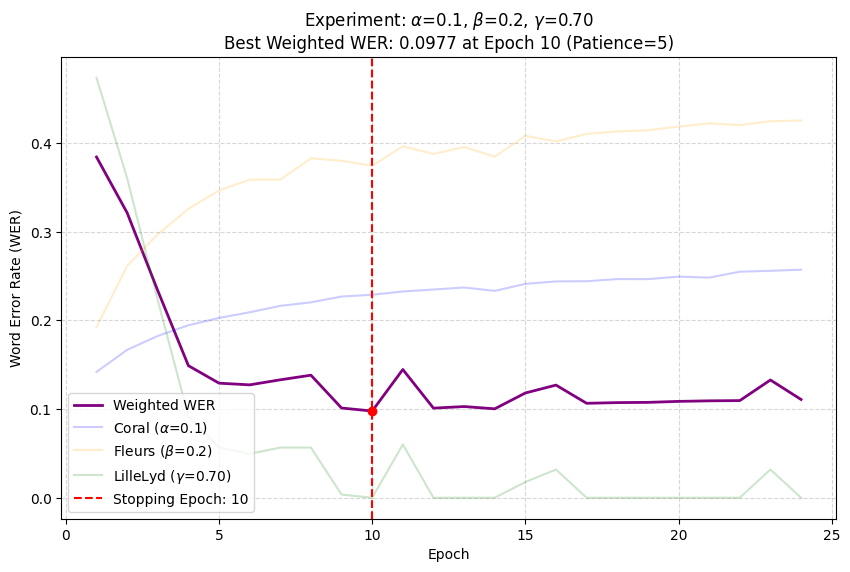

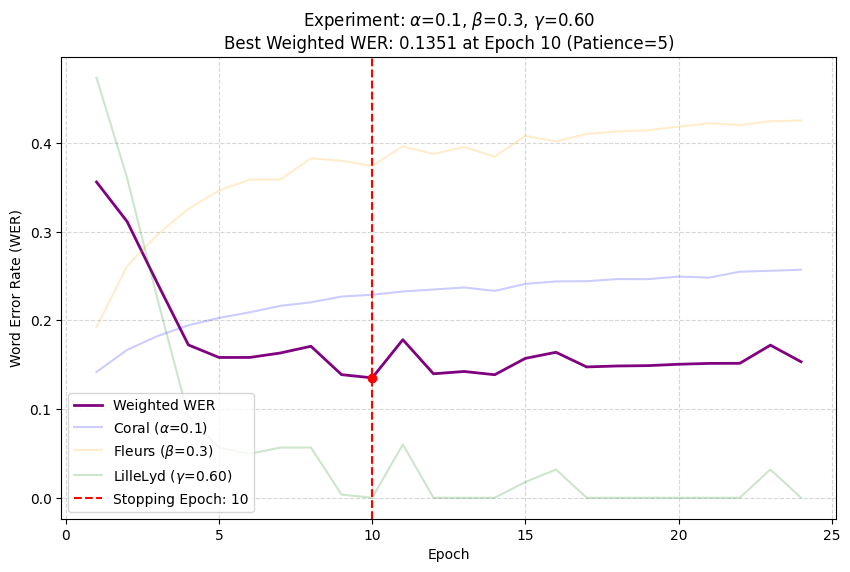

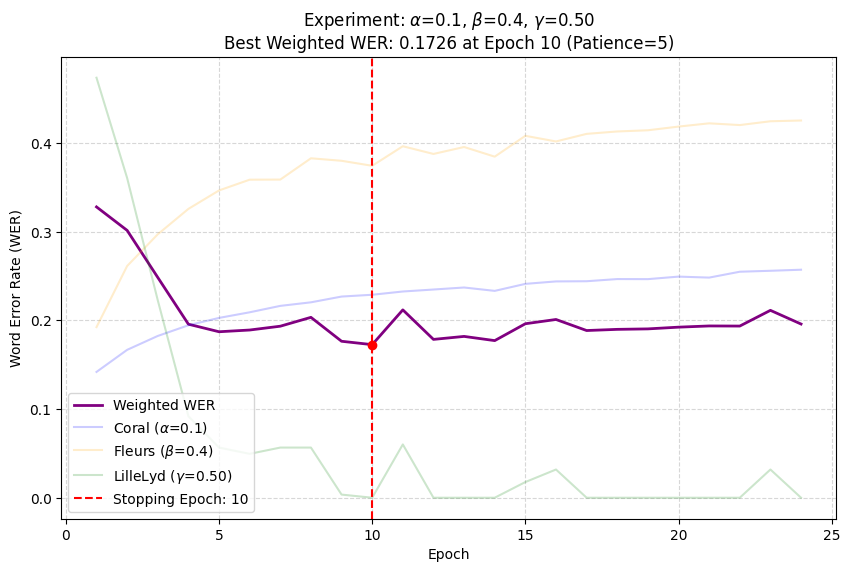

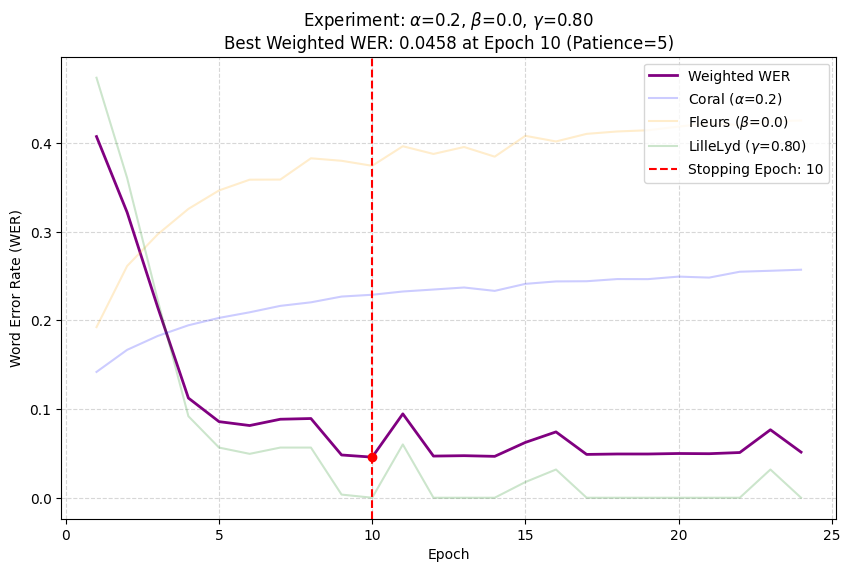

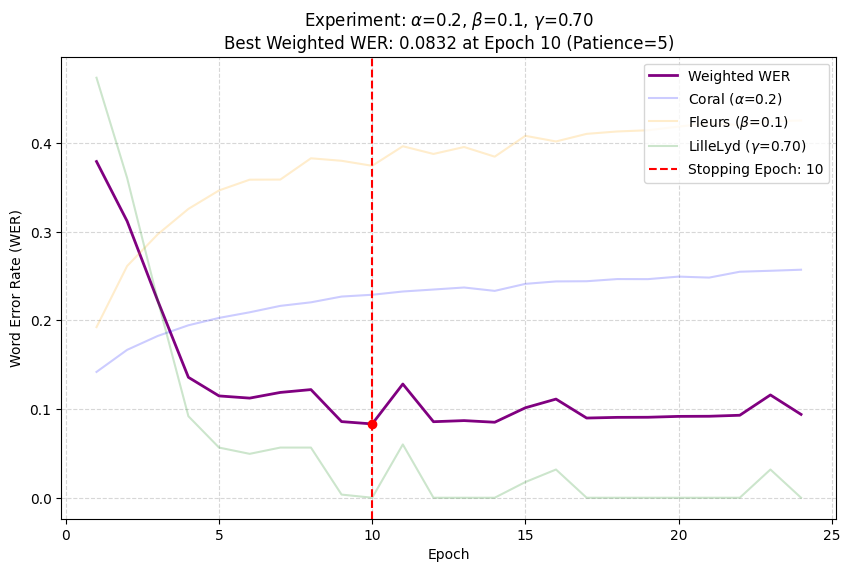

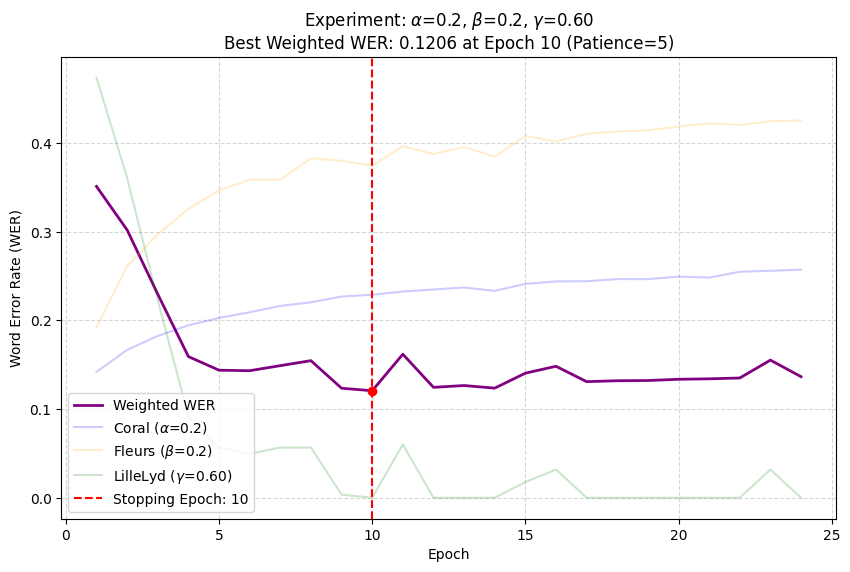

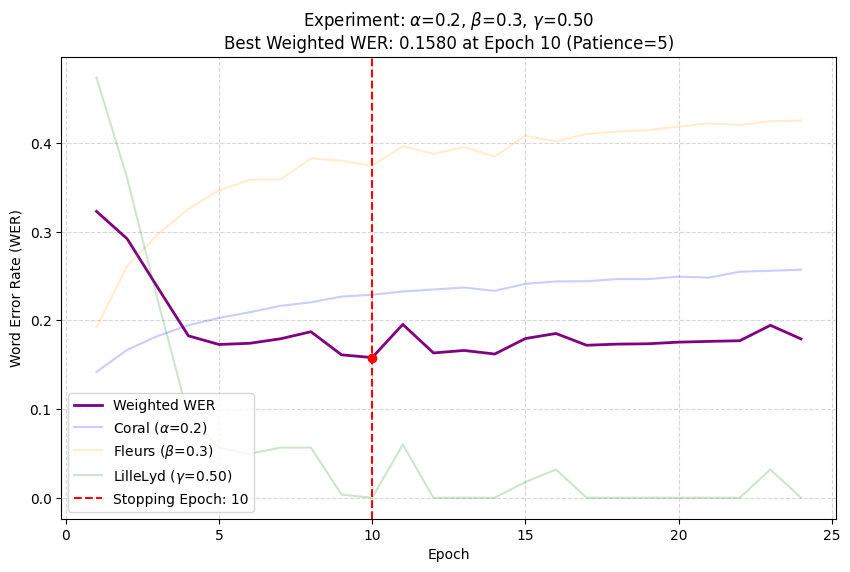

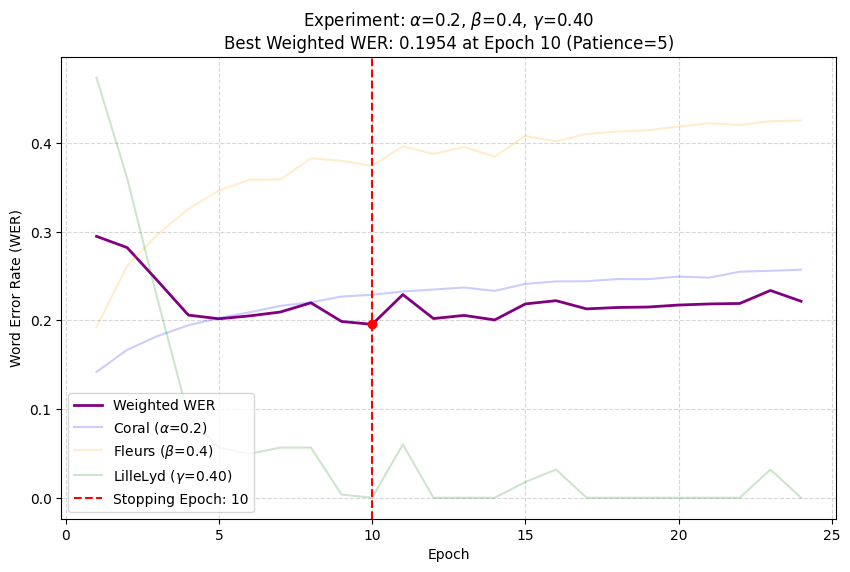

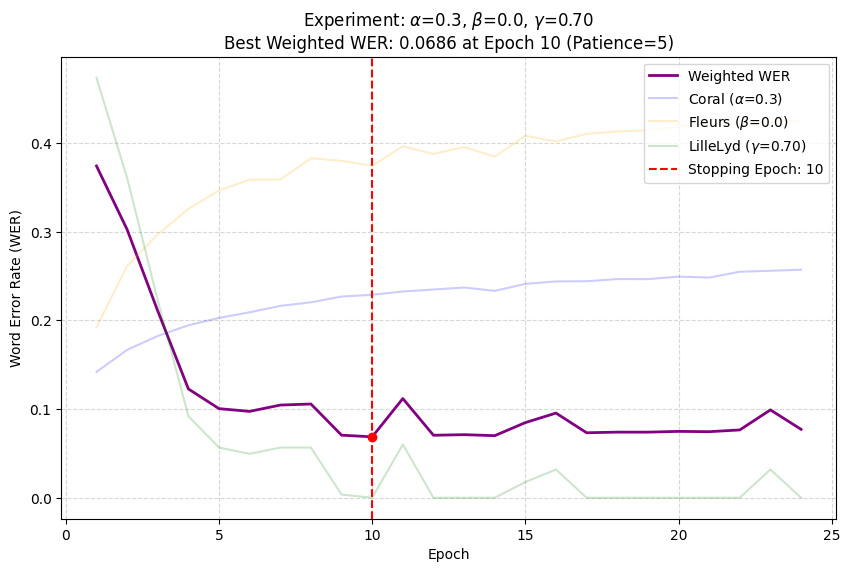

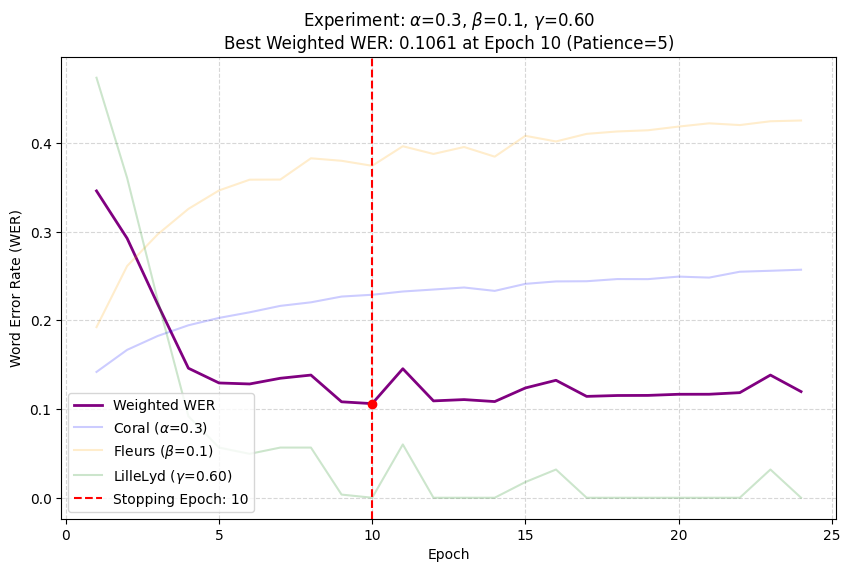

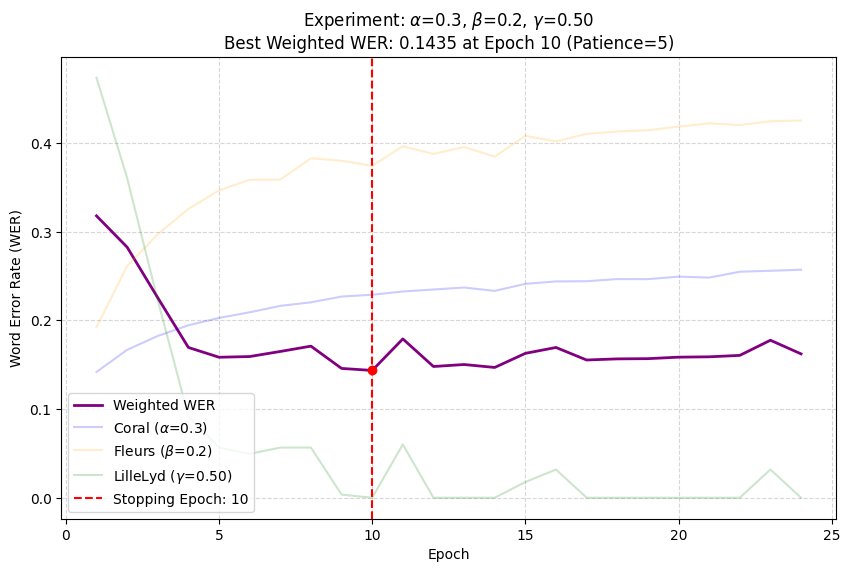

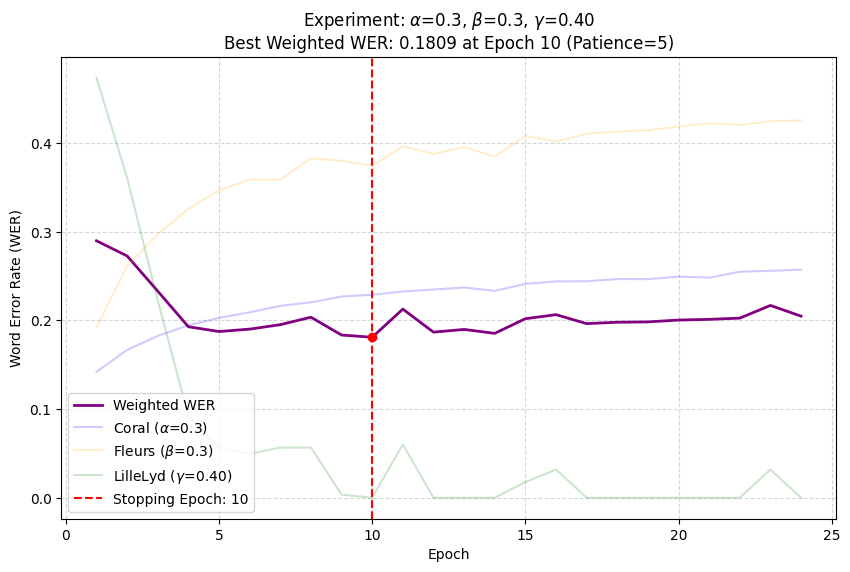

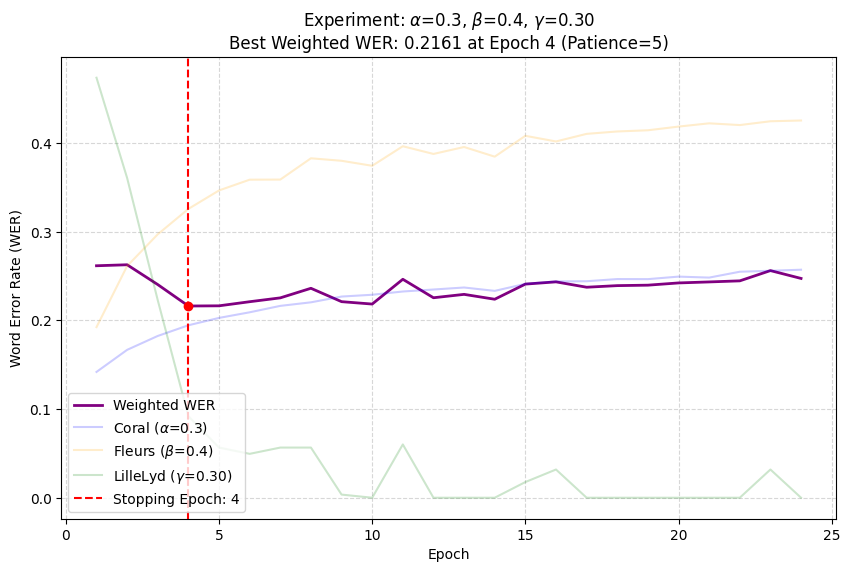

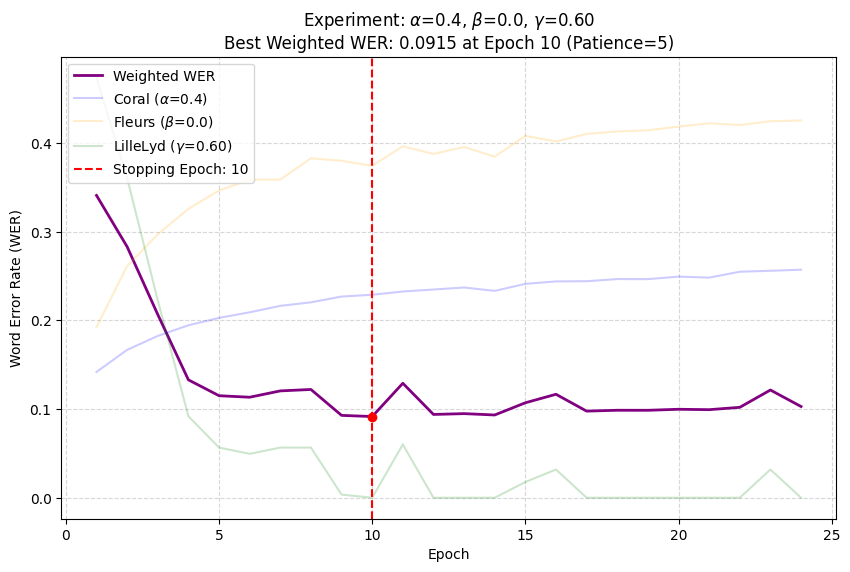

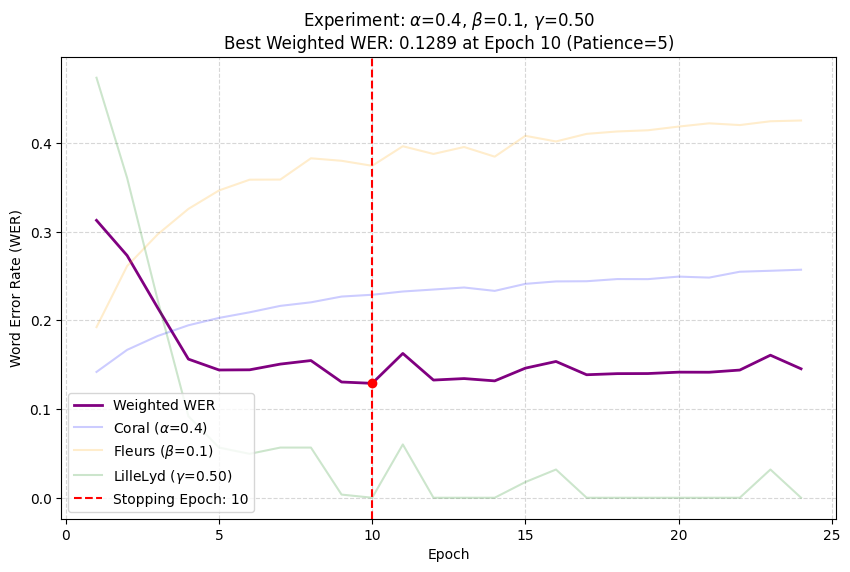

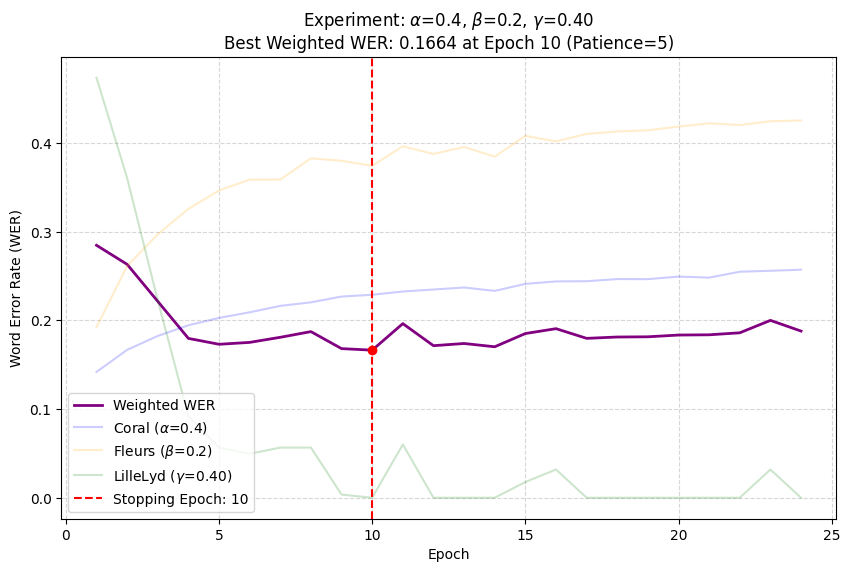

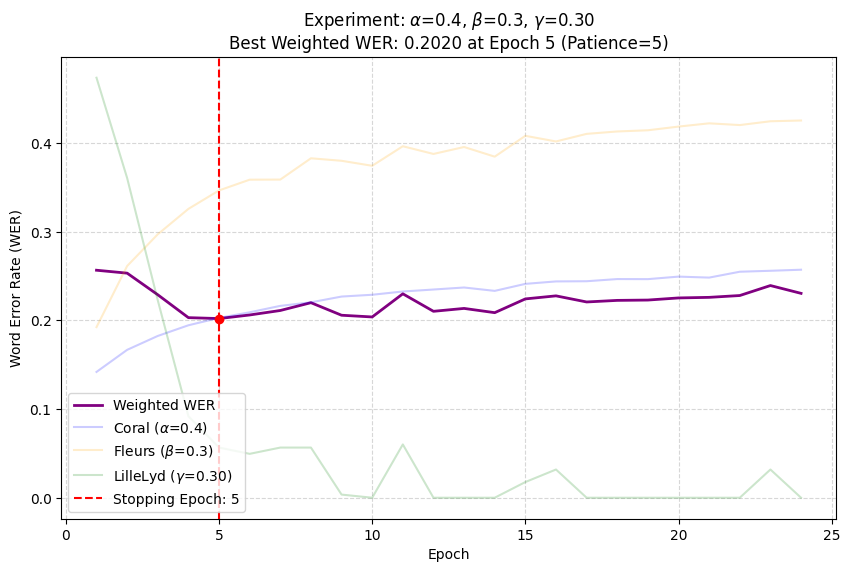

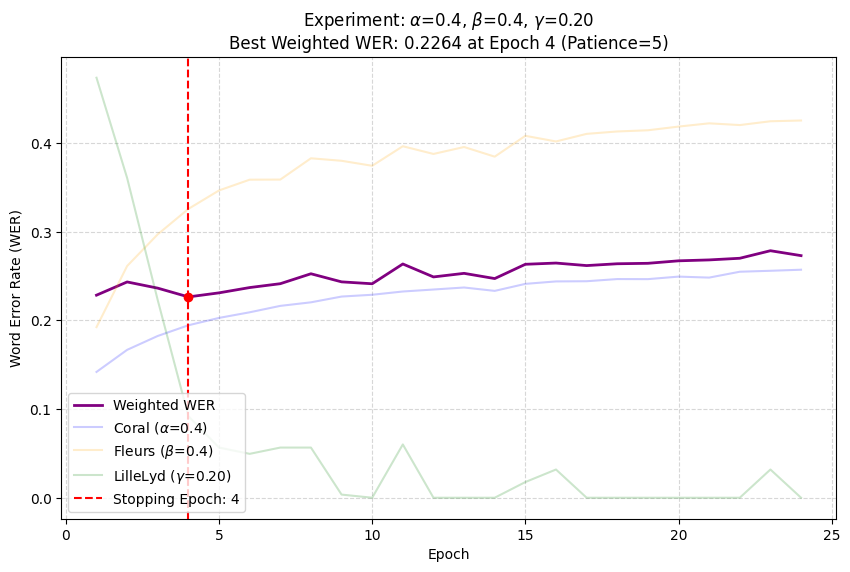

In [156]:
# test different alphas and betas
alphas = [0.1, 0.2, 0.3, 0.4]
betas = [0.0, 0.1, 0.2, 0.3, 0.4]
for alpha in alphas:
    for beta in betas:
        if alpha + beta <= 1.0:
            best_epoch, best_wer = run_wer_experiment(merged_df, alpha=alpha, beta=beta, patience=5)